In [1]:
import sys
sys.path.insert(0, '../../Utilities/')

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from scipy.interpolate import griddata
import time
from itertools import product, combinations
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec
from IPython.display import clear_output, display
import os
from matplotlib.animation import FuncAnimation

run_ID = '001'
%matplotlib inline

In [2]:
# List all available devices
devices = tf.config.list_physical_devices('GPU')
if devices:
    print(f"TensorFlow is using the following GPU(s): {devices}")
else:
    print("No GPU found, running on CPU.")
np.random.seed(1234)
tf.random.set_seed(1234)

class PhysicsInformedNN:
    def __init__(self, x, y, t, u, v, layers, pretrain_path=None, layers_to_freeze=None):
        # Normal initialization
        X = np.concatenate([x, y, t], 1)
        self.lb = X.min(0)
        self.ub = X.max(0)

        self.x = tf.convert_to_tensor(X[:, 0:1], dtype=tf.float32)
        self.y = tf.convert_to_tensor(X[:, 1:2], dtype=tf.float32)
        self.t = tf.convert_to_tensor(X[:, 2:3], dtype=tf.float32)

        self.u = tf.convert_to_tensor(u, dtype=tf.float32)
        self.v = tf.convert_to_tensor(v, dtype=tf.float32)

        self.layers = layers
        self.weights, self.biases = self.initialize_NN(layers)        
        self.lambda_1 = tf.Variable(0.0, dtype=tf.float32, name="lambda_1")
        self.lambda_2 = tf.Variable(0.0, dtype=tf.float32, name="lambda_2")
        self.optimizer = tf.keras.optimizers.Adam()
        self.loss_history = []

        # Load weights from pre-trained model if provided
        if pretrain_path is not None:
            self.load_model(pretrain_path)

        # Track frozen layers
        self.frozen_indices = layers_to_freeze if layers_to_freeze else []

        # Print frozen layers
        print("Frozen Layers:")
        for idx in self.frozen_indices:
            print(f"Hidden Layer {idx + 1} (Size: {layers[idx]} nodes)")

    def initialize_NN(self, layers):        
        weights = []
        biases = []
        num_layers = len(layers) 
        for l in range(0, num_layers - 1):
            W = tf.Variable(
                self.xavier_init(size=[layers[l], layers[l + 1]]), 
                dtype=tf.float32, 
                name=f'weight_layer_{l}'
            )
            b = tf.Variable(
                tf.zeros([1, layers[l + 1]], dtype=tf.float32), 
                dtype=tf.float32, 
                name=f'bias_layer_{l}'
            )
            weights.append(W)
            biases.append(b)        
        return weights, biases
    
    def xavier_init(self, size):
        in_dim = size[0]
        out_dim = size[1]        
        xavier_stddev = np.sqrt(2 / (in_dim + out_dim))
        return tf.Variable(tf.random.truncated_normal([in_dim, out_dim], stddev=xavier_stddev), dtype=tf.float32)
    
    def neural_net(self, X, weights, biases):
        num_layers = len(weights) + 1
        
        H = 2.0 * (X - self.lb) / (self.ub - self.lb) - 1.0
        for l in range(0, num_layers-2):
            W = weights[l]
            b = biases[l]
            H = tf.tanh(tf.add(tf.matmul(H, W), b))
        W = weights[-1]
        b = biases[-1]
        Y = tf.add(tf.matmul(H, W), b)
        return Y
    
    def net_NS(self, x, y, t):
        lambda_1 = self.lambda_1
        lambda_2 = self.lambda_2
    
        # Use a single GradientTape to compute both first and second derivatives
        with tf.GradientTape(persistent=True) as tape:
            tape.watch([x, y, t])
            
            # Forward pass through the neural network
            psi_and_p = self.neural_net(tf.concat([x, y, t], 1), self.weights, self.biases)
            psi = psi_and_p[:, 0:1]  # Stream function
            p = psi_and_p[:, 1:2]    # Pressure
    
            # First-order derivatives
            u = tape.gradient(psi, y)  # u = d(psi)/dy
            v = -tape.gradient(psi, x)  # v = -d(psi)/dx
            
            # Print first-order derivatives to debug
            #print(f"u: {u}, v: {v}")
    
            if u is None or v is None:
                raise ValueError("Error: First-order derivatives u or v are None.")
    
            # Second-order derivatives
            u_t = tape.gradient(u, t)
            u_x = tape.gradient(u, x)
            u_y = tape.gradient(u, y)
            v_t = tape.gradient(v, t)
            v_x = tape.gradient(v, x)
            v_y = tape.gradient(v, y)
    
            # Second-order spatial derivatives
            u_xx = tape.gradient(u_x, x)
            u_yy = tape.gradient(u_y, y)
            v_xx = tape.gradient(v_x, x)
            v_yy = tape.gradient(v_y, y)
            p_x = tape.gradient(p, x)
            p_y = tape.gradient(p, y)
    
            # Debug second-order gradients
            #print(f"u_xx: {u_xx}, u_yy: {u_yy}, v_xx: {v_xx}, v_yy: {v_yy}")
    
            if u_xx is None or u_yy is None or v_xx is None or v_yy is None:
                raise ValueError("Error: Second-order derivatives are None.")
    
        # Free up memory by deleting tape
        del tape
    
        # Navier-Stokes equations
        f_u = u_t + lambda_1 * (u * u_x + v * u_y) + p_x - lambda_2 * (u_xx + u_yy)
        f_v = v_t + lambda_1 * (u * v_x + v * v_y) + p_y - lambda_2 * (v_xx + v_yy)
    
        return u, v, p, f_u, f_v

    @tf.function
    def loss(self):
        u_pred, v_pred, p_pred, f_u_pred, f_v_pred = self.net_NS(self.x, self.y, self.t)
        loss_value = tf.reduce_mean(tf.square(self.u - u_pred)) + \
                     tf.reduce_mean(tf.square(self.v - v_pred)) + \
                     tf.reduce_mean(tf.square(f_u_pred)) + \
                     tf.reduce_mean(tf.square(f_v_pred))
        return loss_value

    
    @tf.function
    def train_step(self):
        with tf.GradientTape() as tape:
            loss_value = self.loss()
        
        # Get gradients for all trainable variables
        trainable_vars = []
        for idx, (w, b) in enumerate(zip(self.weights, self.biases)):
            if idx not in self.frozen_indices:  # Skip frozen layers
                trainable_vars.extend([w, b])
        
        trainable_vars.extend([self.lambda_1, self.lambda_2])  # Always include these
        
        gradients = tape.gradient(loss_value, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))
        return loss_value

    def train(self, nIter):
        start_time = time.time()
        for it in range(nIter):
            loss_value = self.train_step()
            self.loss_history.append(loss_value.numpy())
            
            # Print the progress
            if it % 10 == 0:
                elapsed = time.time() - start_time
                lambda_1_value = self.lambda_1.numpy()
                lambda_2_value = self.lambda_2.numpy()
                print(f'It: {it}, Loss: {loss_value:.3e}, l1: {lambda_1_value:.3f}, l2: {lambda_2_value:.5f}, Time: {elapsed:.2f}')
                start_time = time.time()
                if it % 5000 == 0 and it > 0:
                    self.save_model(f'models/checkpoints/{run_ID}_checkpoint_{it}.npz')

    def plot_loss_history(self, save_path=f'plots/savehistory_{run_ID}'):
        plt.figure(figsize=(10, 6))
        plt.plot(self.loss_history, label='Loss History')
        plt.xlabel('Iteration')
        plt.ylabel('Loss')
        plt.yscale('log')
        plt.title('Loss History During Training')
        plt.legend()
        plt.grid(True)
        plt.savefig(save_path)
        print(f"Loss history plot saved to {save_path}")
        
    def predict(self, x_star, y_star, t_star):
        x_star = tf.convert_to_tensor(x_star, dtype=tf.float32)
        y_star = tf.convert_to_tensor(y_star, dtype=tf.float32)
        t_star = tf.convert_to_tensor(t_star, dtype=tf.float32)
        
        u_pred, v_pred, p_pred, _, _ = self.net_NS(x_star, y_star, t_star)
        return u_pred.numpy(), v_pred.numpy(), p_pred.numpy()

    def save_model(self, path):
        # Create a dictionary to store weights, biases, and parameters
        save_dict = {}
    
        # Save each weight and bias separately in the dictionary
        for i, w in enumerate(self.weights):
            save_dict[f"weight_{i}"] = w.numpy()  # Convert each weight to a NumPy array
        for i, b in enumerate(self.biases):
            save_dict[f"bias_{i}"] = b.numpy()    # Convert each bias to a NumPy array
    
        # Save the trainable parameters (lambda_1, lambda_2)
        save_dict["lambda_1"] = self.lambda_1.numpy()  # Convert lambda_1 to a NumPy array
        save_dict["lambda_2"] = self.lambda_2.numpy()  # Convert lambda_2 to a NumPy array
    
        # Save the dictionary to an .npz file
        np.savez(path, **save_dict)
    
        print(f"Model saved to {path}")


    def load_model(self, path, load_weights=True, load_params=True):
        data = np.load(path, allow_pickle=True)
            
        if load_weights:
            for i in range(len(self.weights)):
                weight_key = f'weight_{i}'
                bias_key = f'bias_{i}'
                    
                if weight_key in data and bias_key in data:
                    self.weights[i].assign(tf.convert_to_tensor(data[weight_key]))
                    self.biases[i].assign(tf.convert_to_tensor(data[bias_key]))
            
        if load_params:
            if 'lambda_1' in data and 'lambda_2' in data:
                self.lambda_1.assign(tf.convert_to_tensor(data['lambda_1']))
                self.lambda_2.assign(tf.convert_to_tensor(data['lambda_2']))
    
        print(f"Model loaded from {path}")
        

No GPU found, running on CPU.


In [3]:
def axisEqual3D(ax):
    extents = np.array([getattr(ax, 'get_{}lim'.format(dim))() for dim in 'xyz'])
    sz = extents[:,1] - extents[:,0]
    centers = np.mean(extents, axis=1)
    maxsize = max(abs(sz))
    r = maxsize/4
    for ctr, dim in zip(centers, 'xyz'):
        getattr(ax, 'set_{}lim'.format(dim))(ctr - r, ctr + r)

In [4]:
def newfig(width, height):
    fig = plt.figure(figsize=(width, height))
    ax = fig.add_subplot(111)
    return fig, ax
    

In [5]:
def plot_solution(X_star, u_star, index, title):
    
    lb = X_star.min(0)
    ub = X_star.max(0)
    nn = 200
    x = np.linspace(lb[0], ub[0], nn)
    y = np.linspace(lb[1], ub[1], nn)
    X, Y = np.meshgrid(x,y)
    
    U_star = griddata(X_star, u_star.flatten(), (X, Y), method='cubic')
    
    plt.figure(index)
    plt.pcolor(X,Y,U_star, cmap = 'jet')
    plt.title(title)
    plt.colorbar()
    

In [6]:
def visualize_training_data(x_train, y_train, t_train, re_number):
    # Create the 3D plot
    fig = plt.figure(figsize=(10, 5))
    gs1 = gridspec.GridSpec(1, 2)
    gs1.update(top=0.8, bottom=0.1, left=0.05, right=0.95, wspace=0.4)

    ax = plt.subplot(gs1[:, 0], projection='3d')
    ax.axis('off')

    # Determine ranges for axes
    r1 = [x_train.min(), x_train.max()]
    r2 = [t_train.min(), t_train.max()]
    r3 = [y_train.min(), y_train.max()]

    # Draw bounding box
    for s, e in combinations(np.array(list(product(r1, r2, r3))), 2):
        if np.sum(np.abs(s - e)) == r1[1] - r1[0] or np.sum(np.abs(s - e)) == r2[1] - r2[0] or np.sum(np.abs(s - e)) == r3[1] - r3[0]:
            ax.plot3D(*zip(s, e), color="k", linewidth=0.5)

    # Plot training data points
    ax.scatter(x_train, t_train, y_train, s=0.3)

    # Add axis labels
    ax.set_xlabel('$x$')
    ax.set_ylabel('$t$')
    ax.set_zlabel('$y$')
    ax.text(x_train.mean(), t_train.min() - 1, y_train.min() - 1, '$x$')
    ax.text(x_train.max() + 1, t_train.mean(), y_train.min() - 1, '$t$')
    ax.text(x_train.min() - 1, t_train.min() - 0.5, y_train.mean(), '$y$')
    ax.text(x_train.min() - 3, t_train.mean(), y_train.max() + 1, f'$u(t,x,y)$ for $Re = {re_number}$')
    ax.set_xlim3d(r1)
    ax.set_ylim3d(r2)
    ax.set_zlim3d(r3)

    # Set equal aspect ratio
    axisEqual3D(ax)

    # Display the plot
    plt.show()
    

In [7]:
def run_model_for_reynolds(model, coord_data, vel_data, P_data, TT, Re, model_path, plot_solution):
    # Load the model
    model.load_model(model_path)

    # Test Data at t=0
    snap = np.array([0])
    x_test = coord_data[:, 0:1]
    y_test = coord_data[:, 1:2]
    t_test = TT[:, snap]
    u_test = vel_data[:, 0, snap]
    v_test = vel_data[:, 1, snap]
    p_test = P_data[:, snap]
    
    ######################################################################
    ###################### Specifying Desired Domain #####################
    ######################################################################

    print(f'Choose Domain for Prediction (Re = {Re})')
    x_min_new = float(input("Minimum X value: "))  # New minimum x value
    x_max_new = float(input("Maximum X value: "))  # New maximum x value
    y_min_new = float(input("Minimum Y value: "))  # New minimum y value
    y_max_new = float(input("Maximum Y value: "))  # New maximum y value

    # Define the number of points for the extended grid
    num_points_x = 100  # Change this value to generate more points
    num_points_y = 100  # Change this value to generate more points

    # Generate the new extended x and y arrays
    x_new = np.linspace(x_min_new, x_max_new, num_points_x)
    y_new = np.linspace(y_min_new, y_max_new, num_points_y)

    # Create the meshgrid for the new points
    X_new, Y_new = np.meshgrid(x_new, y_new)

    # Flatten the arrays to get them in the same shape as X_star (N x 1)
    x_extended = X_new.flatten()[:, None]
    y_extended = Y_new.flatten()[:, None]

    # Recreate grid again for plotting
    coord_grid_extended = np.hstack((x_extended, y_extended))

    # Choose a specific value
    value = float(input(f"What time point would you like to see the velocity field for (Re = {Re})? "))
    t_at_point = np.full((coord_grid_extended.shape[0], 1), value)

    ######################################################################
    ###################### Model Predictions #############################
    ######################################################################

    # Predict for test data
    u_pred, v_pred, p_pred = model.predict(x_test, y_test, t_test)
    lambda_1_value = model.lambda_1.numpy()
    lambda_2_value = model.lambda_2.numpy()

    # Predict for extended domain
    u_at_point, v_at_point, p_at_point = model.predict(x_extended, y_extended, t_at_point)

    # Compute errors
    error_u = np.linalg.norm(u_test - u_pred, 2) / np.linalg.norm(u_test, 2)
    error_v = np.linalg.norm(v_test - v_pred, 2) / np.linalg.norm(v_test, 2)
    error_lambda_1 = np.abs(lambda_1_value - 1.0) * 100
    error_lambda_2 = np.abs(lambda_2_value - 0.01) / 0.01 * 100

    # Print errors
    print(f'Error u: {error_u:.2e}')
    print(f'Error v: {error_v:.2e}')
    print(f'Error lambda_1: {error_lambda_1:.5f}%')
    print(f'Error lambda_2: {error_lambda_2:.5f}%')

    ######################################################################
    ###################### Visualization #################################
    ######################################################################

    # Plot extended domain predictions
    plot_solution(coord_grid_extended, u_at_point, 1, f"U Extended (Re = {Re})")
    plot_solution(coord_grid_extended, v_at_point, 2, f"V Extended (Re = {Re})")
    plot_solution(coord_grid_extended, p_at_point, 3, f"P Extended (Re = {Re})")

    ######################################################################
    ###################### Interpolation for Plotting ####################
    ######################################################################

    lb = coord_data.min(0)
    ub = coord_data.max(0)
    nn = 200
    x = np.linspace(lb[0], ub[0], nn)
    y = np.linspace(lb[1], ub[1], nn)
    X, Y = np.meshgrid(x, y)

    lb_ext = coord_grid_extended.min(0)
    ub_ext = coord_grid_extended.max(0)
    nn_ext = 500
    x_ext = np.linspace(lb_ext[0], ub_ext[0], nn_ext)
    y_ext = np.linspace(lb_ext[1], ub_ext[1], nn_ext)
    X_ext, Y_ext = np.meshgrid(x_ext, y_ext)

    # Interpolate onto smaller grid
    UU_pred = griddata(coord_data, u_pred.flatten(), (X, Y), method='cubic')
    VV_pred = griddata(coord_data, v_pred.flatten(), (X, Y), method='cubic')
    PP_pred = griddata(coord_data, p_pred.flatten(), (X, Y), method='cubic')

    UU_at_point = griddata(coord_grid_extended, u_at_point.flatten(), (X_ext, Y_ext), method='cubic')
    VV_at_point = griddata(coord_grid_extended, v_at_point.flatten(), (X_ext, Y_ext), method='cubic')
    PP_at_point = griddata(coord_grid_extended, p_at_point.flatten(), (X_ext, Y_ext), method='cubic')

    # Return predictions and errors for further processing if needed
    return {
        "u_pred": u_pred,
        "v_pred": v_pred,
        "p_pred": p_pred,
        "u_at_point": u_at_point,
        "v_at_point": v_at_point,
        "p_at_point": p_at_point,
        "errors": {
            "u_error": error_u,
            "v_error": error_v,
            "lambda_1_error": error_lambda_1,
            "lambda_2_error": error_lambda_2
        }
    }
    

In [8]:
# Loading data for Reynolds number 100
vel_data_Re100 = scipy.io.loadmat('data/Cyl100/ustar_Aug24')['ustar']  # N x 2 x T
t_data_Re100 = scipy.io.loadmat('data/Cyl100/tstar')['tstar']    # T x 1
coord_data_Re100 = scipy.io.loadmat('data/Cyl100/xstar')['xstar']  # N x 2
P_data_Re100 = scipy.io.loadmat('data/Cyl100/pstar')['pstar']

N_Re100 = coord_data_Re100.shape[0]
T_Re100 = t_data_Re100.shape[0]
TT_Re100 = np.tile(t_data_Re100, (1, N_Re100)).T
PP_Re100 = P_data_Re100  # N x T

# Specify the time domain (start and end times)
time_start_Re100 = 0  # Replace with your desired start time index
time_end_Re100 = 1000  # Replace with your desired end time index ('dt = 0.08')
num_time_points_Re100 = 40  # Number of points to select within this range

selected_time_indices_Re100 = np.linspace(time_start_Re100, time_end_Re100, num_time_points_Re100).astype(int)
t_data_spec_Re100 = t_data_Re100[selected_time_indices_Re100]

# Spatial domain setup for Re100
x_start_Re100, x_end_Re100 = 1, 8
y_start_Re100, y_end_Re100 = -2, 2

# Create a linear space with specified points
num_points_x_Re100 = 50  # Nx
num_points_y_Re100 = 30  # Ny
x_values_Re100 = np.linspace(x_start_Re100, x_end_Re100, num_points_x_Re100)
y_values_Re100 = np.linspace(y_start_Re100, y_end_Re100, num_points_y_Re100)

# Create a meshgrid for the new linearly spaced x and y values
X_spec_Re100, Y_spec_Re100 = np.meshgrid(x_values_Re100, y_values_Re100)

# Combine X and Y coordinates into a single array
coord_grid_spec_Re100 = np.column_stack((X_spec_Re100.ravel(), Y_spec_Re100.ravel()))  # (450, 2)

# Compute distances from the origin (0,0)
distances_from_origin_Re100 = np.sqrt(coord_grid_spec_Re100[:, 0]**2 + coord_grid_spec_Re100[:, 1]**2)

# Filter out points within the cylinder of radius 0.5
cylinder_radius_Re100 = 0.5
valid_points_mask_Re100 = distances_from_origin_Re100 > cylinder_radius_Re100

# Keep only the points outside the cylinder
coord_grid_spec_filtered_Re100 = coord_grid_spec_Re100[valid_points_mask_Re100]

# Interpolated data arrays for Re100
UU_spec_filtered_Re100 = np.zeros((coord_grid_spec_filtered_Re100.shape[0], num_time_points_Re100))  # (valid_points_count, 10)
VV_spec_filtered_Re100 = np.zeros((coord_grid_spec_filtered_Re100.shape[0], num_time_points_Re100))  # (valid_points_count, 10)

# Interpolation for each selected time point
for i, t_idx_Re100 in enumerate(selected_time_indices_Re100):
    UU_spec_filtered_Re100[:, i] = griddata(coord_data_Re100, vel_data_Re100[:, 0, t_idx_Re100], coord_grid_spec_filtered_Re100, method='cubic')
    VV_spec_filtered_Re100[:, i] = griddata(coord_data_Re100, vel_data_Re100[:, 1, t_idx_Re100], coord_grid_spec_filtered_Re100, method='cubic')

# Initialize the grid with NaNs and place the valid values for Re100
UU_data_Re100 = np.full((num_points_y_Re100 * num_points_x_Re100, num_time_points_Re100), np.nan)  # Initialize with NaNs
VV_data_Re100 = np.full((num_points_y_Re100 * num_points_x_Re100, num_time_points_Re100), np.nan)  # Initialize with NaNs

# Place the filtered/interpolated data back into the grid, skipping invalid points
UU_data_Re100[valid_points_mask_Re100, :] = UU_spec_filtered_Re100
VV_data_Re100[valid_points_mask_Re100, :] = VV_spec_filtered_Re100

# Reshape to original grid shape minus invalid points (filtered points remain as NaN)
UU_data_Re100 = UU_data_Re100.reshape((num_points_y_Re100, num_points_x_Re100, num_time_points_Re100))
VV_data_Re100 = VV_data_Re100.reshape((num_points_y_Re100, num_points_x_Re100, num_time_points_Re100))

# Prepare training data for Re100
x_train_spec_Re100 = np.tile(X_spec_Re100.flatten()[valid_points_mask_Re100, None], (num_time_points_Re100, 1))
y_train_spec_Re100 = np.tile(Y_spec_Re100.flatten()[valid_points_mask_Re100, None], (num_time_points_Re100, 1))
t_train_spec_Re100 = np.repeat(t_data_spec_Re100.flatten(), np.sum(valid_points_mask_Re100))[:, None]
u_train_spec_Re100 = UU_spec_filtered_Re100.T.reshape(-1, 1)
v_train_spec_Re100 = VV_spec_filtered_Re100.T.reshape(-1, 1)

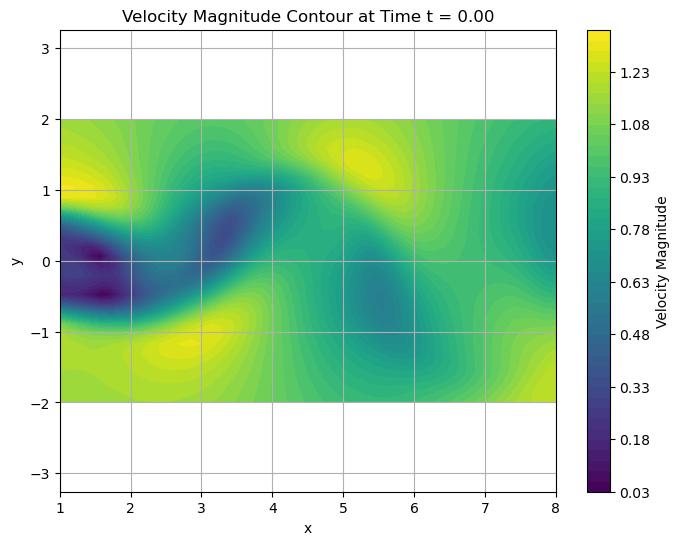

In [10]:
# Compute velocity magnitude for contours
velocity_magnitude = np.sqrt(UU_data_Re100**2 + VV_data_Re100**2)

# Create grid for spatial domain
x_values_Re100 = X_spec_Re100[0, :]  # X coordinates
y_values_Re100 = Y_spec_Re100[:, 0]  # Y coordinates

# Setup figure
fig, ax = plt.subplots(figsize=(8, 6))

# Initial contour plot
contour = ax.contourf(x_values_Re100, y_values_Re100, velocity_magnitude[:, :, 0], levels=50, cmap='viridis')
colorbar = plt.colorbar(contour, ax=ax)
colorbar.set_label("Velocity Magnitude")

# Title, labels, and grid setup
ax.set_title("Velocity Magnitude Contour at Time t = 0.00")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.axis('equal')
ax.grid(True)

# Update function for animation
def update(frame):
    ax.clear()  # Clear the axes for new data
    contour = ax.contourf(x_values_Re100, y_values_Re100, velocity_magnitude[:, :, frame], levels=50, cmap='viridis')
    ax.set_title(f"Velocity Magnitude Contour at Time t = {t_data_spec_Re100[frame][0]:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.axis('equal')
    ax.grid(True)
    return contour

# Create animation
anim = FuncAnimation(fig, update, frames=num_time_points_Re100, interval=100)

# Save animation as a GIF (ensure Pillow is installed)
anim.save('plots/velocity_magnitude_animation.gif', writer='pillow', fps=10)

In [ ]:
layers = [3, 20, 20, 20, 20, 20, 20, 20, 20, 2]

# Training
print('Training Model...')
model = PhysicsInformedNN(x_train_spec_Re100, y_train_spec_Re100, t_train_spec_Re100, u_train_spec_Re100, v_train_spec_Re100, layers)
nIter = 100  # Number of iterations
model.train(nIter)
model.plot_loss_history(save_path = f'plots/specmodel{run_ID}_loss_history')
print(f'Model Training Complete for {nIter} iterations')

    # Saving the model
save_dir = 'models'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

model.save_model(os.path.join(save_dir, f'specmodel_weights_{run_ID}.npz'))

Training Model...


KeyboardInterrupt: 

In [29]:
# Loading data for Reynolds number 150
vel_data_Re150 = scipy.io.loadmat('data/Cyl150/ustar')['ustar']  # N x 2 x T
t_data_Re150 = scipy.io.loadmat('data/Cyl150/tstar')['t']   # T x 1
x_Re150 = scipy.io.loadmat('data/Cyl150/xstar')['x']  # N x 1
y_Re150 = scipy.io.loadmat('data/Cyl150/xstar')['y']  # N x 1

coord_data_Re150 = np.hstack((x_Re150, y_Re150))

N_Re150 = coord_data_Re150.shape[0]
T_Re150 = t_data_Re150.shape[0]

# Specify the time domain (start and end times)
time_start_Re150 = 0  # Replace with your desired start time index
time_end_Re150 = 250  # Replace with your desired end time index ('dt = 0.08')
num_time_points_Re150 = 10  # Number of points to select within this range

selected_time_indices_Re150 = np.linspace(time_start_Re150, time_end_Re150, num_time_points_Re150).astype(int)
t_data_spec_Re150 = t_data_Re150.T[selected_time_indices_Re150]

# Spatial domain setup for Re150
x_start_Re150, x_end_Re150 = 1, 8
y_start_Re150, y_end_Re150 = -2, 2

# Create a linear space with specified points
num_points_x_Re150 = 35  # Nx
num_points_y_Re150 = 15  # Ny
x_values_Re150 = np.linspace(x_start_Re150, x_end_Re150, num_points_x_Re150)
y_values_Re150 = np.linspace(y_start_Re150, y_end_Re150, num_points_y_Re150)

# Create a meshgrid for the new linearly spaced x and y values
X_spec_Re150, Y_spec_Re150 = np.meshgrid(x_values_Re150, y_values_Re150)

# Combine X and Y coordinates into a single array
coord_grid_spec_Re150 = np.column_stack((X_spec_Re150.ravel(), Y_spec_Re150.ravel()))  # (450, 2)

# Compute distances from the origin (0,0)
distances_from_origin_Re150 = np.sqrt(coord_grid_spec_Re150[:, 0]**2 + coord_grid_spec_Re150[:, 1]**2)

# Filter out points within the cylinder of radius 0.5
cylinder_radius_Re150 = 0.5
valid_points_mask_Re150 = distances_from_origin_Re150 > cylinder_radius_Re150

# Keep only the points outside the cylinder
coord_grid_spec_filtered_Re150 = coord_grid_spec_Re150[valid_points_mask_Re150]

# Interpolated data arrays
UU_spec_filtered_Re150 = np.zeros((coord_grid_spec_filtered_Re150.shape[0], num_time_points_Re150))  # (valid_points_count, 10)
VV_spec_filtered_Re150 = np.zeros((coord_grid_spec_filtered_Re150.shape[0], num_time_points_Re150))  # (valid_points_count, 10)

# Interpolation for each selected time point
for i, t_idx_Re150 in enumerate(selected_time_indices_Re150):
    UU_spec_filtered_Re150[:, i] = griddata(coord_data_Re150, vel_data_Re150[:, 0, t_idx_Re150], coord_grid_spec_filtered_Re150, method='cubic')
    VV_spec_filtered_Re150[:, i] = griddata(coord_data_Re150, vel_data_Re150[:, 1, t_idx_Re150], coord_grid_spec_filtered_Re150, method='cubic')

# Initialize the grid with NaNs and place the valid values
UU_data_Re150 = np.full((num_points_y_Re150 * num_points_x_Re150, num_time_points_Re150), np.nan)  # Initialize with NaNs
VV_data_Re150 = np.full((num_points_y_Re150 * num_points_x_Re150, num_time_points_Re150), np.nan)  # Initialize with NaNs

# Place the filtered/interpolated data back into the grid, skipping invalid points
UU_data_Re150[valid_points_mask_Re150, :] = UU_spec_filtered_Re150
VV_data_Re150[valid_points_mask_Re150, :] = VV_spec_filtered_Re150

# Reshape to original grid shape minus invalid points (filtered points remain as NaN)
UU_data_Re150 = UU_data_Re150.reshape((num_points_y_Re150, num_points_x_Re150, num_time_points_Re150))
VV_data_Re150 = VV_data_Re150.reshape((num_points_y_Re150, num_points_x_Re150, num_time_points_Re150))

x_train_spec_Re150 = np.tile(X_spec_Re150.flatten()[valid_points_mask_Re150, None], (num_time_points_Re150, 1))
y_train_spec_Re150 = np.tile(Y_spec_Re150.flatten()[valid_points_mask_Re150, None], (num_time_points_Re150, 1))
t_train_spec_Re150 = np.repeat(t_data_spec_Re150.flatten(), np.sum(valid_points_mask_Re150))[:, None]
u_train_spec_Re150 = UU_spec_filtered_Re150.T.reshape(-1, 1)
v_train_spec_Re150 = VV_spec_filtered_Re150.T.reshape(-1, 1)

In [66]:
run_ID = 'freeze_test'
model = PhysicsInformedNN(
    x_train_spec_Re150, y_train_spec_Re150, t_train_spec_Re150, u_train_spec_Re150, v_train_spec_Re150, layers=[3, 20, 20, 20, 20, 20, 20, 20, 20, 2], 
    pretrain_path='models/BASE_MODEL.npz', 
    layers_to_freeze=[1, 2]  # Freezes the first two layers (indices 0 and 1)
)
print('Training Model...')
nIter = 5000  # Number of iterations
model.train(nIter)
model.plot_loss_history(save_path = f'plots/testmodel{run_ID}_loss_history')
print(f'Model Training Complete for {nIter} iterations')

    # Saving the model
save_dir = 'models'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

model.save_model(os.path.join(save_dir, f'specmodel_weights_{run_ID}.npz'))

Model loaded from models/BASE_MODEL.npz
Frozen Layers:
Hidden Layer 1 (Size: 3 nodes)
Hidden Layer 2 (Size: 20 nodes)
Training Model...


KeyboardInterrupt: 

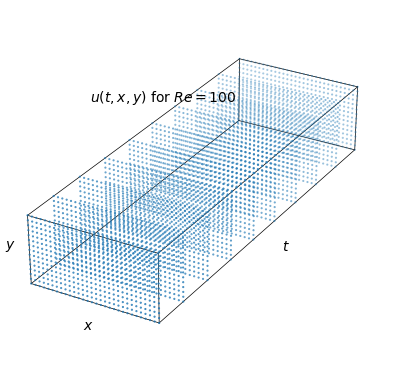

In [42]:
visualize_training_data(x_train_spec_Re100, y_train_spec_Re100, t_train_spec_Re100, re_number=100)

#visualize_training_data(x_train_spec_Re150, y_train_spec_Re150, t_train_spec_Re150, re_number=150)

Model loaded from models/BASE_MODEL_LONG.npz
Choose Domain for Prediction (Re = 100)


Minimum X value:  1
Maximum X value:  8
Minimum Y value:  -2
Maximum Y value:  2
What time point would you like to see the velocity field for (Re = 100)?  0


Error u: 3.83e-01
Error v: 7.51e-01
Error lambda_1: 80.13729%
Error lambda_2: 77.43303%


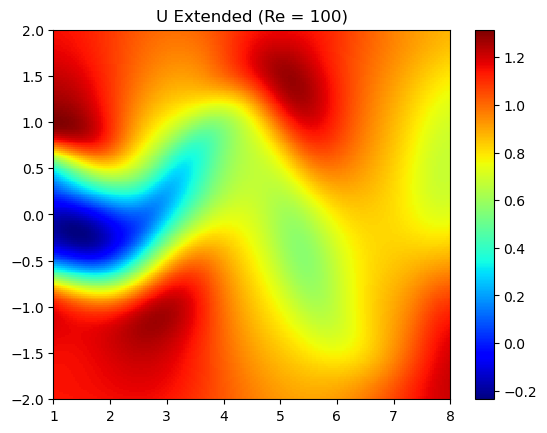

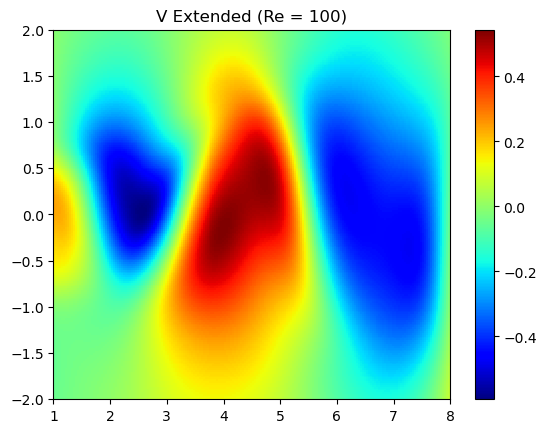

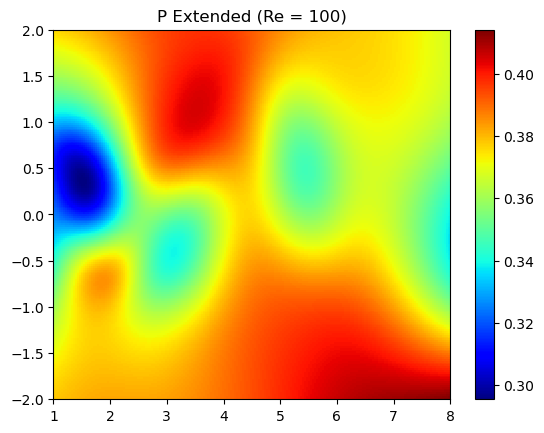

In [94]:
results_re_100 = run_model_for_reynolds(
    model=model,
    coord_data=coord_data_Re100,
    vel_data=vel_data_Re100,
    P_data=P_data_Re100,
    TT=TT_Re100,
    Re=100,
    model_path='models/BASE_MODEL_LONG.npz',
    plot_solution=plot_solution
)


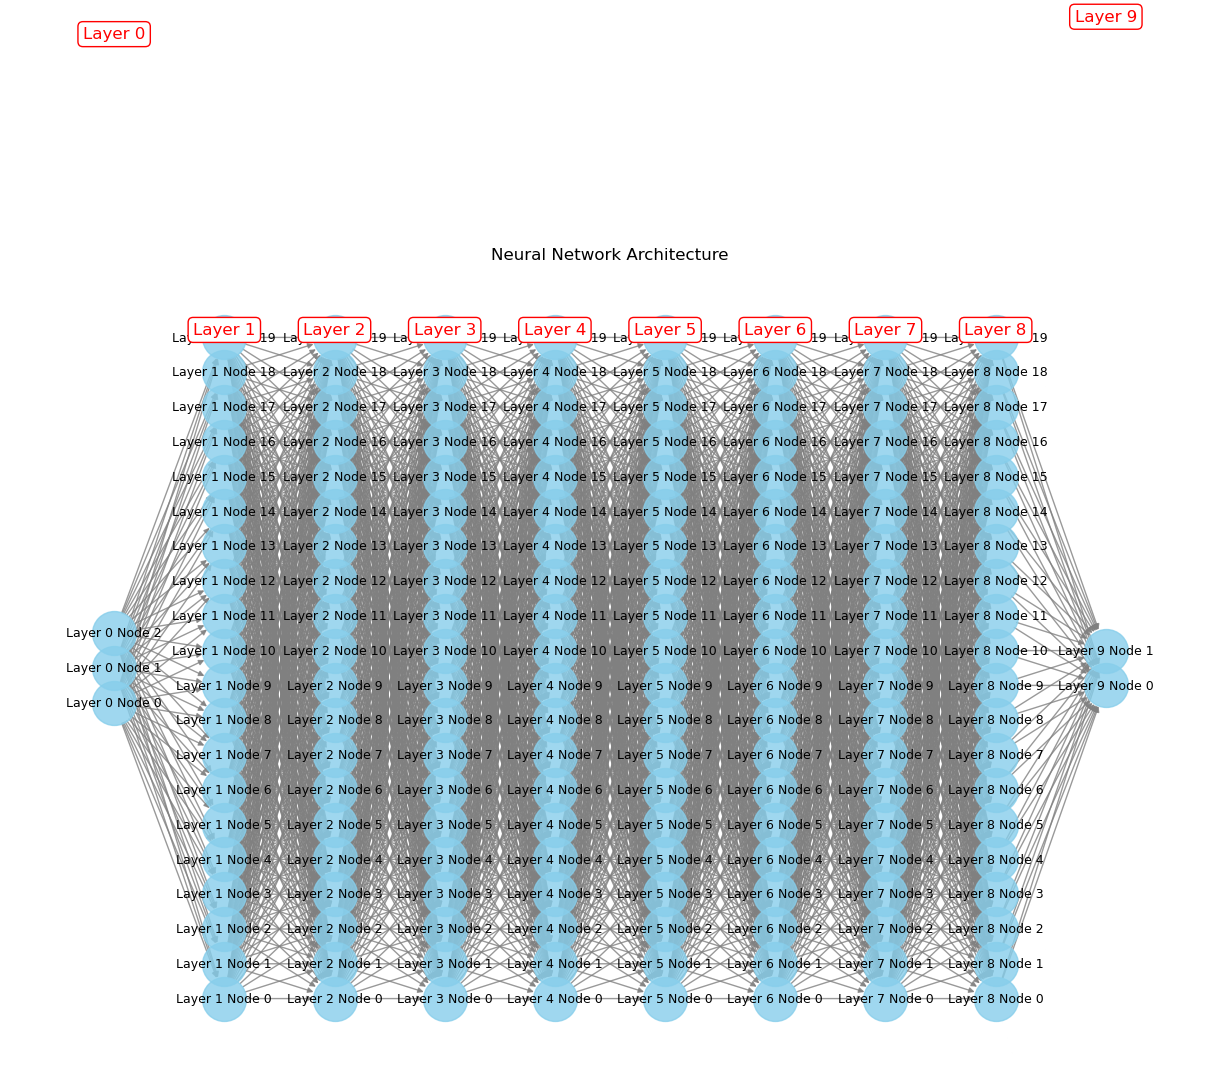

In [93]:
import networkx as nx

def visualize_network(layers):
    """
    Visualize a neural network given its layer sizes.
    
    Parameters:
        layers (list): A list containing the number of nodes in each layer.
                       Example: [3, 10, 10, 1] means 3 input nodes, 2 hidden layers
                       with 10 nodes each, and 1 output node.
    """
    # Create a directed graph
    G = nx.DiGraph()
    
    # Compute node positions layer by layer
    pos = {}  # Dictionary to hold the position of each node
    current_x = 0  # Starting x-coordinate for the first layer
    layer_spacing = 3
    node_spacing = 1.5
    
    for layer_idx, num_nodes in enumerate(layers):
        for node_idx in range(num_nodes):
            pos[f"Layer {layer_idx} Node {node_idx}"] = (current_x, node_spacing * (node_idx - (num_nodes - 1) / 2))
        
        current_x += layer_spacing  # Move to the next layer
    
    # Add nodes and edges
    for layer_idx in range(len(layers) - 1):  # Iterate through layers
        for node_idx in range(layers[layer_idx]):  # Current layer nodes
            for next_node_idx in range(layers[layer_idx + 1]):  # Next layer nodes
                # Add directed edges between current layer and next layer
                G.add_edge(f"Layer {layer_idx} Node {node_idx}", f"Layer {layer_idx + 1} Node {next_node_idx}")
    
    # Draw the network
    plt.figure(figsize=(12, 8))
    nx.draw(
        G,
        pos,
        with_labels=False,
        node_size=1000,
        node_color="skyblue",
        edge_color="gray",
        alpha=0.8,
        arrowsize=8
    )
    
    # Add labels for each layer
    for node, position in pos.items():
        plt.text(position[0], position[1], node, fontsize=9, ha='center', va='center')
    
    # Add layer labels
    for layer_idx, num_nodes in enumerate(layers):
        plt.text(
            pos[f"Layer {layer_idx} Node 0"][0],
            pos[f"Layer {layer_idx} Node 0"][1] + 1.5 * (max(layers) - 1),
            f"Layer {layer_idx}",
            fontsize=12,
            ha='center',
            va='bottom',
            color="red",
            bbox=dict(boxstyle="round,pad=0.3", edgecolor="red", facecolor="white")
        )
        
    plt.title("Neural Network Architecture")
    plt.axis("off")
    plt.show()
layers = [3, 20, 20, 20, 20, 20, 20, 20, 20, 2]
# Example usage
visualize_network(layers)

In [ ]:
######################################################################
#################### find u, v, p at a point #########################
######################################################################   
x_input = float(input("What is the x value of your prediction point: "))
y_input = float(input("What is the y value of your prediction point: "))
t_input = float(input("What is the t value of your prediction point: "))

# Create an array of shape N x 1 filled with the user-provided values
x_user = np.full((1, 1), x_input)
y_user = np.full((1, 1), y_input)
t_user = np.full((1, 1), t_input)

# Prediction for the user-specified point
u_pred_user, v_pred_user, p_pred_user = model.predict(x_user, y_user, t_user)
    
# Output the predictions
print(f"Predicted u at (x={x_input}, y={y_input}, t={t_input}): {u_pred_user[0][0]}")
print(f"Predicted v at (x={x_input}, y={y_input}, t={t_input}): {v_pred_user[0][0]}")
print(f"Predicted p at (x={x_input}, y={y_input}, t={t_input}): {p_pred_user[0][0]}")

What is the x value of your prediction point:  0
What is the y value of your prediction point:  0
What is the t value of your prediction point:  0


Predicted u at (x=0.0, y=0.0, t=0.0): 0.05936022847890854
Predicted v at (x=0.0, y=0.0, t=0.0): -0.026876987889409065
Predicted p at (x=0.0, y=0.0, t=0.0): -0.2161249816417694


In [34]:
######################################################################
#################### Plotting vorticity at t=0 #######################
######################################################################   
data_vort = scipy.io.loadmat('data/cylinder_nektar_t0_vorticity.mat')

x_vort = data_vort['x'] 
y_vort = data_vort['y'] 
w_vort = data_vort['w'] 
modes = (data_vort['modes']).item()
nel = (data_vort['nel']).item()

xx_vort = np.reshape(x_vort, (modes+1,modes+1,nel), order = 'F')
yy_vort = np.reshape(y_vort, (modes+1,modes+1,nel), order = 'F')
ww_vort = np.reshape(w_vort, (modes+1,modes+1,nel), order = 'F')
    
box_lb = np.array([1.0, -2.0])
box_ub = np.array([8.0, 2.0])

box_lb_ext = np.array([x_min_new, y_min_new])
box_ub_ext = np.array([x_max_new, y_max_new])
    
fig, ax = newfig(10, 12)
ax.axis('off')
    
####### Row 0: Vorticity ##################    
gs0 = gridspec.GridSpec(1, 2)
gs0.update(top=1-0.06, bottom=1-2/4 + 0.12, left=0.0, right=1.0, wspace=0)
ax = plt.subplot(gs0[:, :])
    
for i in range(0, nel):
    h = ax.pcolormesh(xx_vort[:,:,i], yy_vort[:,:,i], ww_vort[:,:,i], cmap='seismic',shading='gouraud',  vmin=-3, vmax=3) 
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(h, cax=cax)
    
ax.plot([box_lb[0],box_lb[0]],[box_lb[1],box_ub[1]],'k',linewidth = 1)
ax.plot([box_ub[0],box_ub[0]],[box_lb[1],box_ub[1]],'k',linewidth = 1)
ax.plot([box_lb[0],box_ub[0]],[box_lb[1],box_lb[1]],'k',linewidth = 1)
ax.plot([box_lb[0],box_ub[0]],[box_ub[1],box_ub[1]],'k',linewidth = 1)

ax.plot([box_lb_ext[0],box_lb_ext[0]],[box_lb_ext[1],box_ub_ext[1]],'b',linewidth = 1)
ax.plot([box_ub_ext[0],box_ub_ext[0]],[box_lb_ext[1],box_ub_ext[1]],'b',linewidth = 1)
ax.plot([box_lb_ext[0],box_ub_ext[0]],[box_lb_ext[1],box_lb_ext[1]],'b',linewidth = 1)
ax.plot([box_lb_ext[0],box_ub_ext[0]],[box_ub_ext[1],box_ub_ext[1]],'b',linewidth = 1)
    
ax.set_aspect('equal', 'box')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('Vorticity', fontsize = 10)

# Extract x, y values and u, v components at t = 0
x_t0 = coord_data[:, 0]
y_t0 = coord_data[:, 1]
u_t0 = vel_data[:, 0, 0]
v_t0 = vel_data[:, 1, 0]

# Reshape x, y, u, v into grid form
x_unique_t0 = np.unique(x_t0)
y_unique_t0 = np.unique(y_t0)
X_t0, Y_t0 = np.meshgrid(x_unique_t0, y_unique_t0)

x_unique_ext = np.unique(coord_grid_extended[:,0])
y_unique_ext = np.unique(coord_grid_extended[:,1])
X_ext_vort, Y_ext_vort = np.meshgrid(x_unique_ext, y_unique_ext)

U_t0 = u_t0.reshape(X_t0.shape)
V_t0 = v_t0.reshape(X_t0.shape)

U_pred = u_pred[:,0].reshape(X_t0.shape)
V_pred = v_pred[:,0].reshape(X_t0.shape)

U_pred_ext = u_at_point[:,0].reshape(X_ext_vort.shape)
V_pred_ext = v_at_point[:,0].reshape(Y_ext_vort.shape)

# Calculate the vorticity
dVdx = np.gradient(V_t0, axis=1) / np.gradient(X_t0, axis=1)
dUdy = np.gradient(U_t0, axis=0) / np.gradient(Y_t0, axis=0)
vorticity = dVdx - dUdy
dVdx = np.gradient(V_pred, axis=1) / np.gradient(X_t0, axis=1)
dUdy = np.gradient(U_pred, axis=0) / np.gradient(Y_t0, axis=0)
vorticity_pred = dVdx - dUdy
dVdx = np.gradient(V_pred_ext, axis=1) / np.gradient(X_ext_vort, axis=1)
dUdy = np.gradient(U_pred_ext, axis=0) / np.gradient(Y_ext_vort, axis=0)
vorticity_pred_ext = dVdx - dUdy

# Create subplots
#fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

# Plot the exact vorticity
c1 = ax1.contourf(X_t0, Y_t0, vorticity, levels=100, cmap='jet')
#ax1.contour(X_t0, Y_t0, vorticity, levels=levels_vorticity, colors='black', linewidths=0.5)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_title('DNS Vorticity at t=0')

# Plot the predicted vorticity
c2 = ax2.contourf(X_t0, Y_t0, vorticity_pred, levels=100, cmap='jet')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_title('PINN Predicted Vorticity at t=0')

# Plot the predicted vorticity on extended grid
#c3 = ax3.contourf(X_ext_vort, Y_ext_vort, vorticity_pred_ext, levels=100, cmap='jet')
#ax3.set_xlabel('X')
#ax3.set_ylabel('Y')
#ax3.set_title('Predicted Vorticity for extended domain')

# Create a shared colorbar
fig.colorbar(c1, ax=[ax1, ax2], orientation='vertical', fraction=0.02, pad=0.05, label='Vorticity')

plt.savefig(f'plots/{model_name}_vorticity.png')
plt.show()

NameError: name 'x_min_new' is not defined

NameError: name 'x_test' is not defined

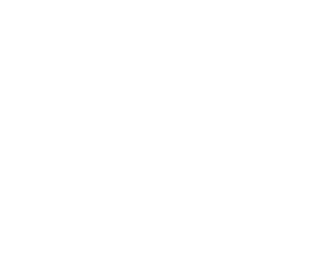

In [35]:
####### Row 1: Training data ##################
########      u(t,x,y)     ###################        
# Create a grid spec
gs1 = gridspec.GridSpec(1, 2)
gs1.update(top=1-2/4, bottom=0.0, left=0.01, right=0.99, wspace=0)

# Create first subplot for u(t,x,y)
ax = plt.subplot(gs1[:, 0],  projection='3d')
ax.axis('off')

r1 = [x_test.min(), x_test.max()]
r2 = [data['t'].min(), data['t'].max()]
r3 = [y_test.min(), y_test.max()]

for s, e in combinations(np.array(list(product(r1,r2,r3))), 2):
    if np.sum(np.abs(s-e)) == r1[1]-r1[0] or np.sum(np.abs(s-e)) == r2[1]-r2[0] or np.sum(np.abs(s-e)) == r3[1]-r3[0]:
        ax.plot3D(*zip(s,e), color="k", linewidth=0.5)   

ax.scatter(x_train, t_train, y_train, s=0.1)
#ax.scatter(x_train_spec, t_train_spec, y_train_spec, s=0.1)
ax.contourf(X, UU_pred, Y, zdir='y', offset=t_test.mean(), cmap='rainbow', alpha=0.8)

ax.text(x_test.mean(), data['t'].min() - 1, y_test.min() - 1, '$x$')
ax.text(x_test.max()+1, data['t'].mean(), y_test.min() - 1, '$t$')
ax.text(x_test.min()-1, data['t'].min() - 0.5, y_test.mean(), '$y$')
ax.text(x_test.min()-3, data['t'].mean(), y_test.max() + 1, '$u(t,x,y)$')
ax.set_xlim3d(r1)
ax.set_ylim3d(r2)
ax.set_zlim3d(r3)
axisEqual3D(ax)

# Create second subplot for v(t,x,y)
ax = plt.subplot(gs1[:, 1],  projection='3d')
ax.axis('off')

r1 = [x_test.min(), x_test.max()]
r2 = [data['t'].min(), data['t'].max()]
r3 = [y_test.min(), y_test.max()]

for s, e in combinations(np.array(list(product(r1,r2,r3))), 2):
    if np.sum(np.abs(s-e)) == r1[1]-r1[0] or np.sum(np.abs(s-e)) == r2[1]-r2[0] or np.sum(np.abs(s-e)) == r3[1]-r3[0]:
        ax.plot3D(*zip(s,e), color="k", linewidth=0.5)   

ax.scatter(x_train, t_train, y_train, s=0.1)
#ax.scatter(x_train_spec, t_train_spec, y_train_spec, s=0.1)
ax.contourf(X, VV_pred, Y, zdir='y', offset=t_test.mean(), cmap='rainbow', alpha=0.8)
ax.contourf(X_ext, VV_at_point, Y_ext, zdir='y', offset=t_at_point.mean(), cmap='seismic', alpha=0.8)
#ax.scatter(x_input, t_input, y_input, color='black', s=10)

ax.text(x_test.mean(), data['t'].min() - 1, y_test.min() - 1, '$x$')
ax.text(x_test.max()+1, data['t'].mean(), y_test.min() - 1, '$t$')
ax.text(x_test.min()-1, data['t'].min() - 0.5, y_test.mean(), '$y$')
ax.text(x_test.min()-3, data['t'].mean(), y_test.max() + 1, '$v(t,x,y)$')
ax.set_xlim3d(r1)
ax.set_ylim3d(r2)
ax.set_zlim3d(r3)
axisEqual3D(ax)

    
######## Row 2: Pressure #######################
########      Predicted p(t,x,y)     ########### 
# Initialize the figure with a larger size
fig = plt.figure(figsize=(20, 10))
levels = np.linspace(-0.6, 0.6, 21)

# Create GridSpec layout
gs2 = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1])
gs2.update(top=0.9, bottom=0.1, left=0.05, right=0.95, wspace=0.3)

# Predicted pressure
ax1 = plt.subplot(gs2[0, 0])
h1 = ax1.imshow(PP_pred, interpolation='nearest', cmap='rainbow', 
              extent=[x_test.min(), x_test.max(), y_test.min(), y_test.max()], 
              origin='lower', aspect='auto')
ax1.set_xlabel('$x$')
ax1.set_ylabel('$y$')
ax1.set_aspect('equal', 'box')
ax1.set_title('Predicted pressure', fontsize=14)
cbar1 = plt.colorbar(h1, ax=ax1, fraction=0.046, pad=0.04)
cbar1.ax.set_ylabel('Pressure')

# Exact pressure
ax2 = plt.subplot(gs2[0, 1])
h2 = ax2.imshow(P_exact, interpolation='nearest', cmap='rainbow', 
              extent=[x_test.min(), x_test.max(), y_test.min(), y_test.max()], 
              origin='lower', aspect='auto')
ax2.set_xlabel('$x$')
ax2.set_ylabel('$y$')
ax2.set_aspect('equal', 'box')
ax2.set_title('Exact pressure', fontsize=14)
cbar2 = plt.colorbar(h2, ax=ax2, fraction=0.046, pad=0.04)
cbar2.ax.set_ylabel('Pressure')

# Extended prediction pressure
ax3 = plt.subplot(gs2[0, 2])
h3 = ax3.imshow(PP_at_point, interpolation='nearest', cmap='rainbow', 
              extent=[x_ext.min(), x_ext.max(), y_ext.min(), y_ext.max()], 
              origin='lower', aspect='auto')
ax3.set_xlabel('$x$')
ax3.set_ylabel('$y$')
ax3.set_aspect('equal', 'box')
ax3.set_title('Extended predicted pressure', fontsize=14)
cbar3 = plt.colorbar(h3, ax=ax3, fraction=0.046, pad=0.04)
cbar3.ax.set_ylabel('Pressure')

# plt.savefig(f'plots/{model_name}_pressure.png')

# Show plot
plt.show()

In [37]:
# Loading the model
model_path = 'models/BASE_MODEL.npz'
model.load_model(model_path)

# Extract the model name from the path for use in filenames
model_name = os.path.basename(os.path.dirname(model_path))

snap_indices = np.linspace(0, TT.shape[1] - 1, 100).astype(int)
for snap in snap_indices:
    t_test = TT[:, snap:snap+1]
    u_test = vel_data[:, 0, snap]
    v_test = vel_data[:, 1, snap]
    p_test = P_data[:, snap]
    u_pred, v_pred, p_pred = model.predict(x_test, y_test, t_test)

    U_pred = u_pred[:,0].reshape(X_t0.shape)
    V_pred = v_pred[:,0].reshape(X_t0.shape)

    dVdx = np.gradient(V_pred, axis=1) / np.gradient(X_t0, axis=1)
    dUdy = np.gradient(U_pred, axis=0) / np.gradient(Y_t0, axis=0)
    vorticity_pred = dVdx - dUdy

    # Create subplots
    fig, ax2 = plt.subplots(1, 1, figsize=(20, 6))

    # Plot the predicted vorticity
    c2 = ax2.contourf(X_t0, Y_t0, vorticity_pred, levels=100, cmap='jet')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_title(f'Predicted Vorticity at t = {TT[:, snap:snap+1][0]}')

    # Create a shared colorbar
    cbar = fig.colorbar(c2, ax=ax2, orientation='vertical', fraction=0.02, pad=0.05, label='Vorticity')

    # Display the figure
    plt.show()

    # Clear the current output and close the figure
    clear_output(wait=True)
    plt.close(fig)

clear_output(wait=True)


Model loaded from models/BASE_MODEL.npz


NameError: name 'TT' is not defined

In [24]:
# Loading the model
model_path = 'models/BASE_MODEL.npz'
model.load_model(model_path)

# Extract the model name from the path for use in filenames
model_name = os.path.basename(os.path.dirname(model_path))


snap_indices = np.linspace(0, TT.shape[1] - 1, 100).astype(int)
for snap in snap_indices:
    t_test = TT[:, snap:snap+1]
    u_test = vel_data[:, 0, snap]
    v_test = vel_data[:, 1, snap]
    p_test = P_data[:, snap]

    # Prediction
    u_pred, v_pred, p_pred = model.predict(x_test, y_test, t_test)

    # Interpolate onto smaller grid
    lb = coord_data.min(0)
    ub = coord_data.max(0)
    nn = 200
    x = np.linspace(lb[0], ub[0], nn)
    y = np.linspace(lb[1], ub[1], nn)
    X, Y = np.meshgrid(x, y)

    lb_ext = coord_grid_extended.min(0)
    ub_ext = coord_grid_extended.max(0)
    nn_ext = 500
    x_ext = np.linspace(lb_ext[0], ub_ext[0], nn_ext)
    y_ext = np.linspace(lb_ext[1], ub_ext[1], nn_ext)
    X_ext, Y_ext = np.meshgrid(x_ext, y_ext)
    
    UU_pred = griddata(coord_data, u_pred.flatten(), (X, Y), method='cubic')
    VV_pred = griddata(coord_data, v_pred.flatten(), (X, Y), method='cubic')
    PP_pred = griddata(coord_data, p_pred.flatten(), (X, Y), method='cubic')
    P_exact = griddata(coord_data, p_test.flatten(), (X, Y), method='cubic')

    ######## Row 2: Pressure #######################
    ########      Predicted p(t,x,y)     ########### 
    # Initialize the figure with a larger size
    fig = plt.figure(figsize=(20, 10))
    levels = np.linspace(-0.6, 0.6, 21)

    # Create GridSpec layout
    gs2 = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1])
    gs2.update(top=0.9, bottom=0.1, left=0.05, right=0.95, wspace=0.3)

    # Predicted pressure
    ax1 = plt.subplot(gs2[0, 0])
    h1 = ax1.imshow(PP_pred, interpolation='nearest', cmap='rainbow', 
                extent=[x_test.min(), x_test.max(), y_test.min(), y_test.max()], 
                origin='lower', aspect='auto')
    ax1.set_xlabel('$x$')
    ax1.set_ylabel('$y$')
    ax1.set_aspect('equal', 'box')
    ax1.set_title('Predicted pressure', fontsize=14)
    cbar1 = plt.colorbar(h1, ax=ax1, fraction=0.046, pad=0.04)
    cbar1.ax.set_ylabel('Pressure')

    # Exact pressure
    ax2 = plt.subplot(gs2[0, 1])
    h2 = ax2.imshow(P_exact, interpolation='nearest', cmap='rainbow', 
                extent=[x_test.min(), x_test.max(), y_test.min(), y_test.max()], 
                origin='lower', aspect='auto')
    ax2.set_xlabel('$x$')
    ax2.set_ylabel('$y$')
    ax2.set_aspect('equal', 'box')
    ax2.set_title('Exact pressure', fontsize=14)
    cbar2 = plt.colorbar(h2, ax=ax2, fraction=0.046, pad=0.04)
    cbar2.ax.set_ylabel('Pressure')

# Clear the current output, update the plot, and display it
    clear_output(wait=True)
    display(fig)
    plt.close(fig)

clear_output(wait=True)

Model loaded from models/BASE_MODEL.npz


IndexError: index 1 is out of bounds for axis 0 with size 1

Model loaded from models/BASE_MODEL_LONG.npz


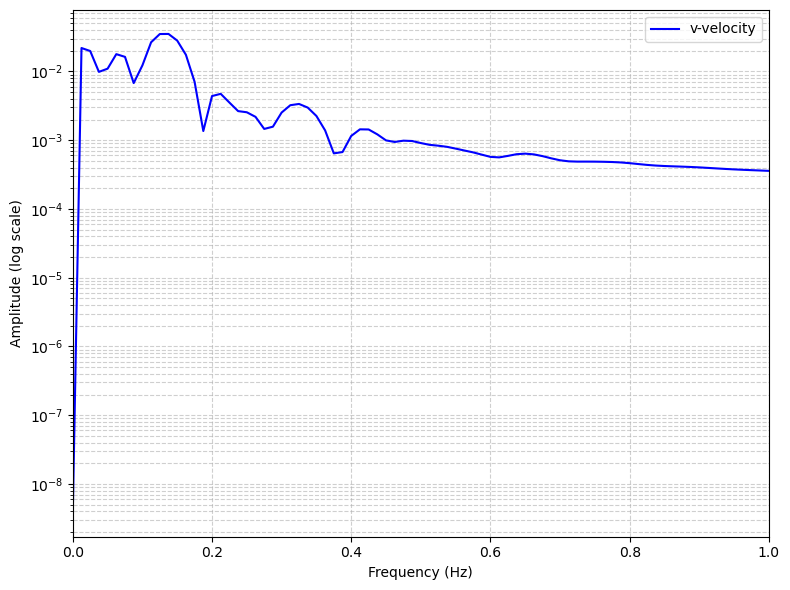

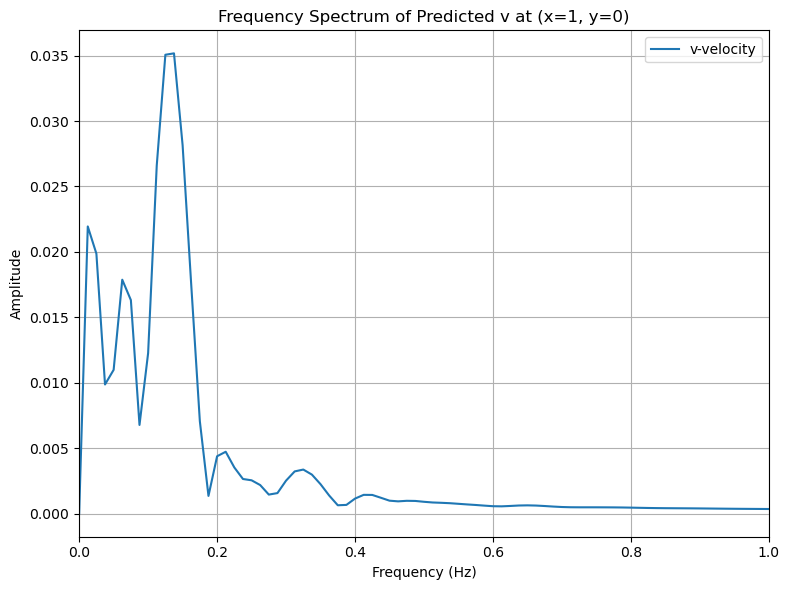

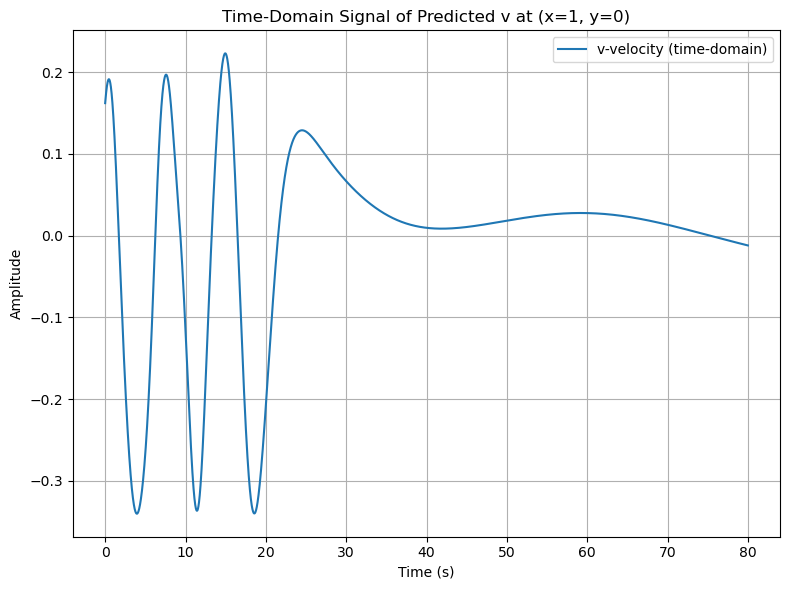

[0.00000000e+00 1.00012502e-02 2.00025003e-02 ... 7.99799975e+01
 7.99899987e+01 8.00000000e+01]


In [114]:
model_path = 'models/BASE_MODEL_LONG.npz'
model.load_model(model_path)

# Define the spatial point of interest
x_input = 1.0  # x-coordinate
y_input = 0.0  # y-coordinate

# Define the time range for sampling
t_values = np.linspace(0, 80, 8000)  # Time values from 0 to 20 seconds, 2000 samples

# Prepare arrays for prediction
x_user = np.full((len(t_values), 1), x_input)
y_user = np.full((len(t_values), 1), y_input)
t_user = t_values.reshape(-1, 1)

# Get predictions from the trained PINN model
u_pred_user, v_pred_user, p_pred_user = model.predict(x_user, y_user, t_user)

# Choose a signal for FFT (e.g., velocity component u)
signal = v_pred_user.flatten() - np.mean(v_pred_user)  # Normalize the signal

# Perform FFT
dt = t_values[1] - t_values[0]  # Time step
fs = 1 / dt  # Sampling frequency
fft_result = np.fft.fft(signal)
frequencies = np.fft.fftfreq(len(signal), dt)
amplitude = np.abs(fft_result) / len(signal)  # Normalize amplitude

# Plot the frequency spectrum with a log scale on the y-axis
plt.figure(figsize=(8, 6))
plt.semilogy(frequencies[:len(frequencies)//2], amplitude[:len(amplitude)//2], label="v-velocity", color='blue')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (log scale)")
plt.grid(True, which="both", linestyle='--', alpha=0.6)
plt.xlim(0, 1)  # Set x-axis range from 0 to 5
plt.legend()
plt.tight_layout()
plt.show()

# Plot the frequency spectrum on a linear scale
plt.figure(figsize=(8, 6))
plt.plot(frequencies[:len(frequencies)//2], amplitude[:len(amplitude)//2], label="v-velocity")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency Spectrum of Predicted v at (x=1, y=0)")
plt.grid()
plt.xlim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

# Plot the time-domain signal
plt.figure(figsize=(8, 6))
plt.plot(t_values, signal, label="v-velocity (time-domain)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Time-Domain Signal of Predicted v at (x=1, y=0)")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()
print(t_values)

In [30]:
print(np.mean(u_pred_user.flatten()))

-0.18038611


In [9]:
pip list

Package                       Version
----------------------------- -----------
absl-py                       2.1.0
aext-assistant                4.0.15
aext-assistant-server         4.0.15
aext-core                     4.0.15
aext-core-server              4.0.15
aext-panels                   4.0.15
aext-panels-server            4.0.15
aext-share-notebook           4.0.15
aext-share-notebook-server    4.0.15
aext-shared                   4.0.15
alabaster                     0.7.16
anaconda-cloud-auth           0.5.1
annotated-types               0.6.0
anyio                         4.2.0
argon2-cffi                   21.3.0
argon2-cffi-bindings          21.2.0
arrow                         1.2.3
astroid                       2.14.2
asttokens                     2.0.5
astunparse                    1.6.3
async-lru                     2.0.4
atomicwrites                  1.4.0
attrs                         23.1.0
autopep8                      2.0.4
Babel                         2.11.0
backc